In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

**Tematyka całego szeregu**
Szereg „All Employees, Construction (CEU2000000001)” przedstawia liczbę zatrudnionych w sektorze budownictwa w Stanach Zjednoczonych (ang. “Construction”) – dokładniej: pracowników zatrudnionych w zakładach objętych badaniem Bureau of Labor Statistics (BLS) w ramach ankiety zakładowej (establishment survey).

* Jednostka: tysiące osób, nie sezonowo korygowana.
* Częstotliwość: miesięczna.
* Zakres: początek od stycznia 1939 r. aż do najnowszych obserwacji (np. sierpień 2025 r.). 
* Źródło danych: BLS (Current Employment Statistics – Establishment Survey) i publikacja przez Federal Reserve Bank of St. Louis na platformie FRED. 
* Opis: obejmuje pracujących w sektorze budownictwa, włączając kierowników robót, wykwalifikowanych rzemieślników, mechaników, praktykantów, pomocników, robotników, wykonujących pracę budowlaną, remontową, demontażową czy utrzymaniową, zarówno na placu budowy jak i w zakładach przygotowawczych.

Wczytujemy dane, od razu ustawiając date jako index.

In [2]:
df = pd.read_csv('CEU2000000001.csv', index_col=0, parse_dates=True)

In [3]:
df = df['2012-01-01':'2021-12-31']

In [4]:
print("Liczba obserwacji:", len(df))
print("Pierwsze wiersze:")
print(df.head())

Liczba obserwacji: 120
Pierwsze wiersze:
                  CEU2000000001
observation_date               
2012-01-01                 5237
2012-02-01                 5219
2012-03-01                 5313
2012-04-01                 5488
2012-05-01                 5651


Wypisujemy statystyki opisowe dla naszej kolumny CEU2000000001

In [5]:
print("\nSTATYSTYKI OPISOWE (2012–2021)")
df.describe().round(0).T



STATYSTYKI OPISOWE (2012–2021)


,count,mean,std,min,25%,50%,75%,max
CEU2000000001,120.0,6728.0,699.0,5219.0,6149.0,6830.0,7330.0,7761.0


Szereg zawiera 120 obserwacji (10 lat * 12 miesięcy) z lat 2012 - 2021. Podstawowe statystyki są następujące (wszystko w tys. osób):
- średnia: 6728,
- mediana: 6830,
- odchylenie standardowe: 699,
- minimum: 5129,
- maksimum: 7761,
- kwartyle:
    - Q1: 6149,
    - Q3: 7333.

Rozpiętość wartości wskazuje na istotne zmiany poziomu zatrudnienia w badanym okresie. Odchylenie standardowe rzędu ok. 10% średniej sugeruje wyraźną zmienność, co jest typowe dla danych makroekonomicznych o charakterze cyklicznym.

<Figure size 1000x400 with 0 Axes>

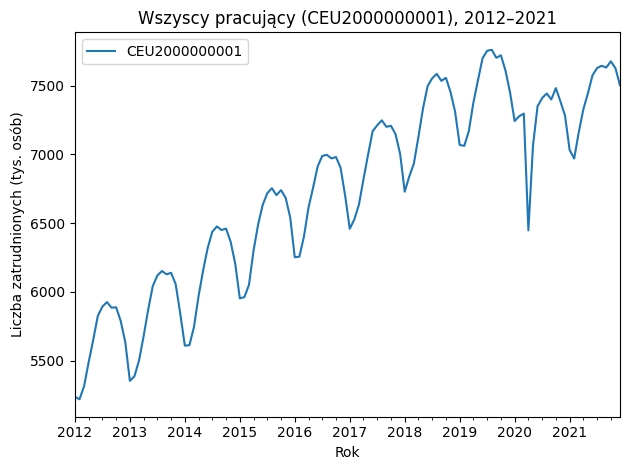

In [6]:
plt.figure(figsize=(10, 4))
df.plot()
plt.title("Wszyscy pracujący (CEU2000000001), 2012–2021")
plt.xlabel("Rok")
plt.ylabel("Liczba zatrudnionych (tys. osób)")
plt.tight_layout()
plt.show()

Z wykresu możemy odczytać:
- długookresowy trend rosnący od 2012 do ok. 2019 roku,
- nastepnie silne załamanie w roku 2020, które można jednoznacznie powiązać z pandemią COVID-19 oraz czasowym zamrożeniem działalności gospodarczej,
- częściową odbudowę w 2021 roku, jednak poziom zatrudnienia nie stabilizuje się na jednym poziomie, lecz wykazuje dalszą zmienność.

Trend nie jest liniowy - widać falowy wzrost z okresowymi spadkami, co sugeruje nakładanie się trendu i sezonowości.

In [10]:
df.groupby(df.index.month).mean()

,CEU2000000001
observation_date,
1,6293.7
2,6311.2
3,6420.9
4,6515.2
5,6731.2
6,6902.6
7,6971.5
8,6998.8
9,6960.9


<Figure size 600x400 with 0 Axes>

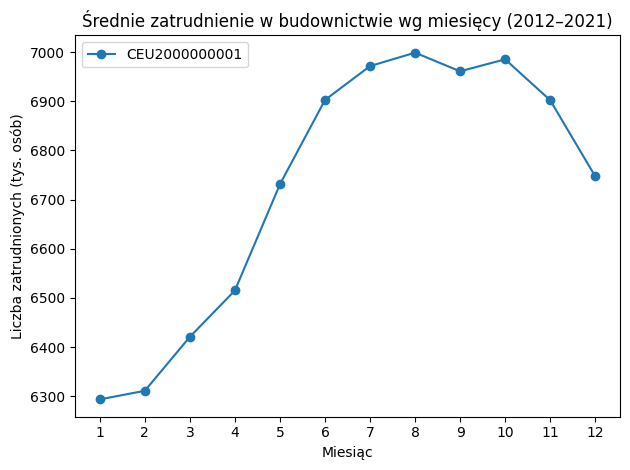

In [7]:
monthly_means = df.groupby(df.index.month).mean()

plt.figure(figsize=(6, 4))
monthly_means.plot(marker="o")
plt.title("Średnie zatrudnienie w budownictwie wg miesięcy (2012–2021)")
plt.xlabel("Miesiąc")
plt.ylabel("Liczba zatrudnionych (tys. osób)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()


Wykres średnich wartości dla poszczególnych miesięcy ujawnia wyraxny wzorzec sezonowy:
- najniższe wartości przypadają na miesiące zimowe: styczeń - luty,
- stopniowy wzrost od marca,
- maksimum w miesiącach letnich (lipiec - sierpień), plus odbicie na październik,
- spadek jesienią i ponowny wyraźny spadek w grudniu.

Jest to zgodne z charakterem sektora budowlanego, silnie uzależnionego od warunków pogodowych.

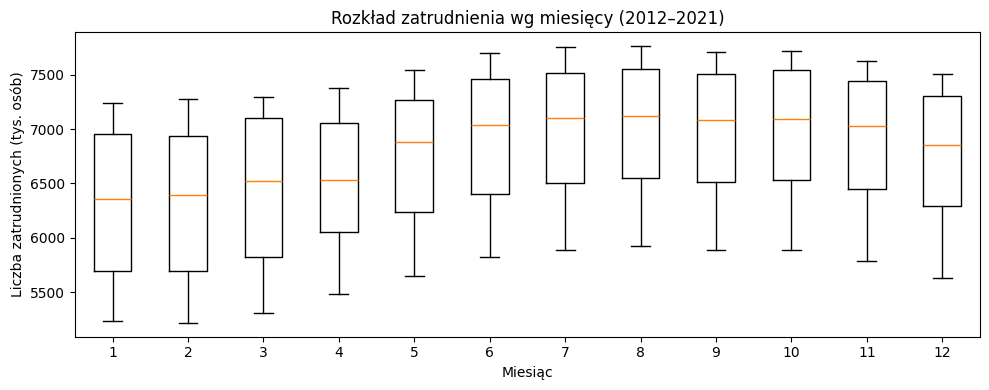

In [8]:
data_by_month = [df[df.index.month == m].iloc[:, 0].values for m in range(1, 13)]

plt.figure(figsize=(10, 4))
plt.boxplot(data_by_month, positions=range(1, 13))
plt.title("Rozkład zatrudnienia wg miesięcy (2012–2021)")
plt.xlabel("Miesiąc")
plt.ylabel("Liczba zatrudnionych (tys. osób)")
plt.tight_layout()
plt.show()

Boxploty potwierdzają:
- systematyczne różnice między miesiącami,
- powtarzalność rozkładów,
- stabilną strukturę sezonową w całym analizowanym okresie.

Sezonowość ma więc charakter deterministyczny i cykliczny o okresie 12 miesięcy.

<Figure size 800x400 with 0 Axes>

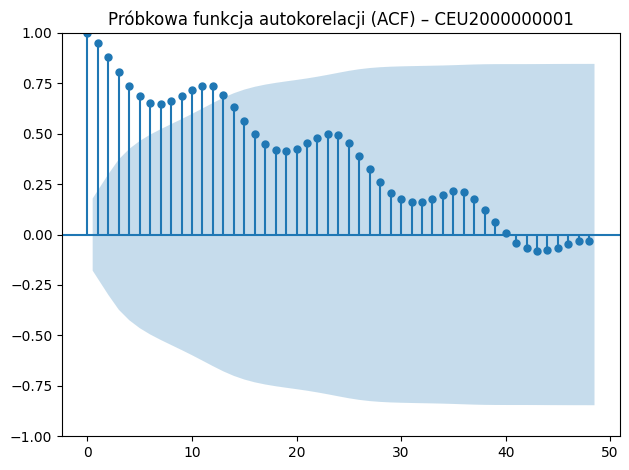

In [9]:
plt.figure(figsize=(8, 4))
plot_acf(df.iloc[:, 0], lags=48)
plt.title("Próbkowa funkcja autokorelacji (ACF) – CEU2000000001")
plt.tight_layout()
plt.show()

Wykres ACF pokazuje:
- bardzo wysoką autokorelację dla małych opóźnień (lag 1 $\approx$ 0.95),
- powolny spadek autokorelacji - charakterystyczny dla szeregów z trendem,
- lokalne maxima co 12 opóźnień, co potwierdza obecnośc sezonowości rocznej.

Taki przebieg ACF świadczy o;
- niestacjonarności w średniej (trend),
- silnej sezonowości,
- długiej pamięci procesu.

Szereg nie spełnia zatem założeń stacjonarności i przed dalszym modelowaniem wymaga transformacji.